# California Housing

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import fetch_california_housing

In [15]:
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

df = X.copy()
df["MedHouseVal"] = y

In [16]:
print("Size of dataset: ", df.shape)
print("\nFirst 5 rows: ")
display(df.head())

Size of dataset:  (20640, 9)

First 5 rows: 


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
print("\nData types:")
print(df.dtypes)


Data types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


| Feature         | Meaning                                   |
|-----------------|-------------------------------------------|
| 0   MedInc      | Median household income in district       |
| 1   HouseAge    | Median age of housing                     | 
| 2   AveRooms    | Average number of rooms per household     |
| 3   AveBedrms   | Average number of bedrooms per household  |
| 4   Population  | The population of district                |
| 5   AveOccup    | Averge number of inhabitans for household |
| 6   Latitude    | Latitude                                  |
| 7   Longitude   | Longitude                                 |

| Target          | Meaning                                                                        |
|-----------------|--------------------------------------------------------------------------------|
| 8   MedHouseVal | Median housing value in the district, expressed in unit of $100,000            |

In [19]:
print("The number of null:\n", df.isna().sum())
print("\nThe share of null:\n", df.isna().mean() * 100)

The number of null:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

The share of null:
 MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
dtype: float64


In [20]:
print("The number of duplicates:", df.duplicated().sum())
print("\nThe number of unique values:\n", df.nunique())

The number of duplicates: 0

The number of unique values:
 MedInc         12928
HouseAge          52
AveRooms       19392
AveBedrms      14233
Population      3888
AveOccup       18841
Latitude         862
Longitude        844
MedHouseVal     3842
dtype: int64


In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


### Target analysis

In [22]:
print("Statistics of the arget variable:")
print(y.describe())

Statistics of the arget variable:
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


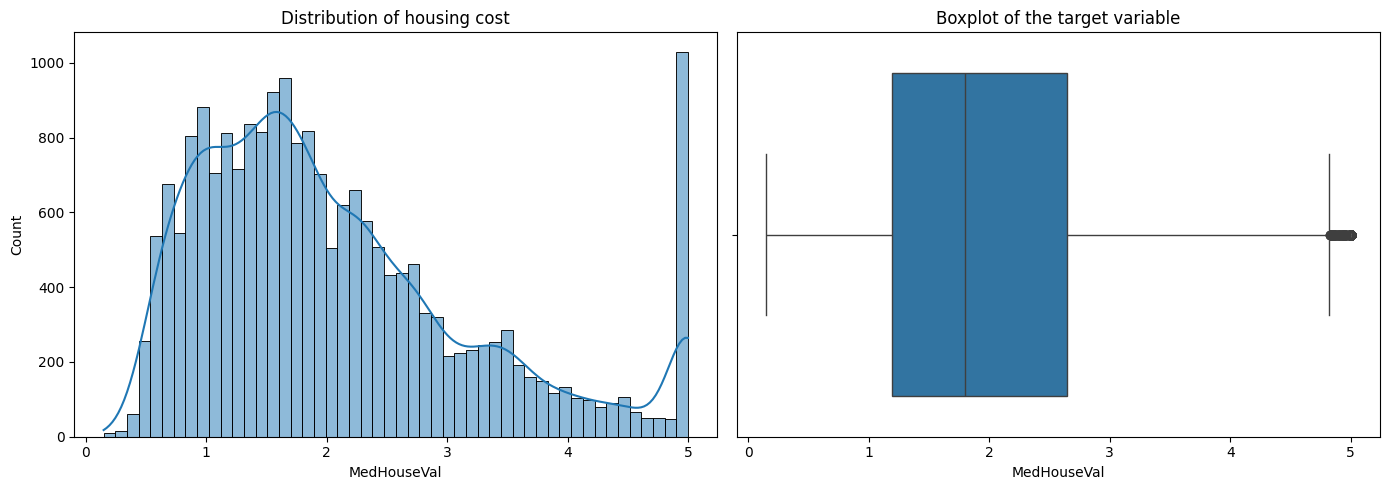

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(y, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of housing cost")
axes[0].set_xlabel("MedHouseVal")

sns.boxplot(x=y, ax=axes[1])
axes[1].set_title("Boxplot of the target variable")

plt.tight_layout()
plt.show()

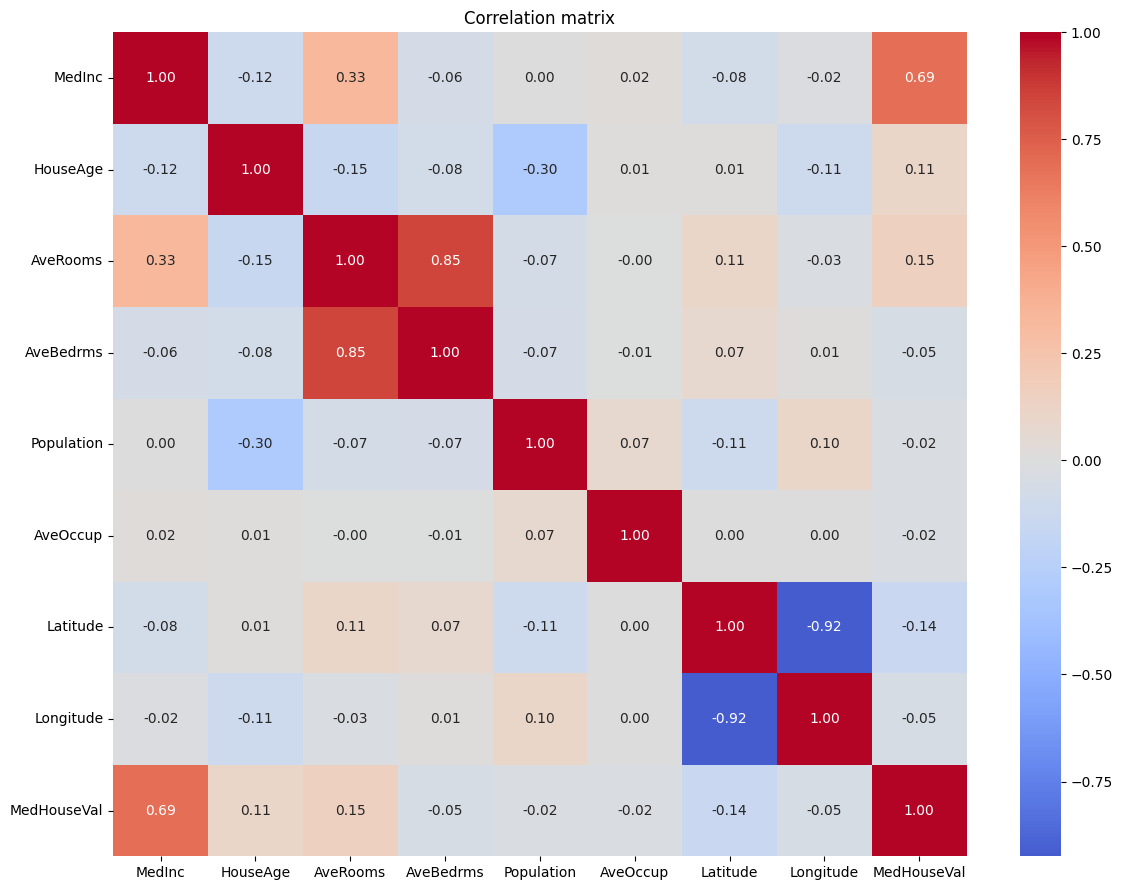

In [26]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation matrix")
plt.tight_layout()
plt.show()